# PROG8431 - Group Assignment 1
**Team Members:**
1. Sukhchain Singh (ID: 9111541)
2. Preethi (ID: 87654321)
3. Arya (ID: 45678912)

## What is Our Project About?

Imagine you run a city bike-sharing program with thousands of bicycles parked at stations around the city. On a warm, sunny day, hundreds of people want to rent bikes. On a cold, rainy day, almost nobody rides. 

If you put out too few bikes on a nice day, customers get disappointed. If you put out too many on a rainy day, bikes sit unused.

In this project, we analyze 731 real days of bike rentals alongside daily weather metrics (like temperature, humidity, and season). Our goal is to uncover patterns so the company knows exactly how many bikes to prepare tomorrow!

## Data source and research question

We use the daily file from the UCI Bike Sharing Dataset. Each row represents one day in the Capital Bikeshare system during 2011–2012 and includes rental counts, calendar information, and weather measurements. The dataset has 731 daily records and no missing values according to UCI.

**Research question:** How do daily temperature and season relate to total bike rentals? This question helps operators understand when demand tends to be higher, although this descriptive analysis does not establish cause and effect.

**Source:** Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894. Dataset page: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset.

The project currently loads a downloaded local copy from data/day.csv; the source download step is not automated in this notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib_venn import venn2

# Ensure plots show directly in the notebook
%matplotlib inline

## Data cleansing

The source describes `day.csv` as daily rental and weather records with no missing values. Before analysis, we check for duplicate rows, translate the normalized temperature and humidity fields into easier-to-read units, rename key columns, and map the season codes to their documented labels. UCI defines season codes as 1 = Winter, 2 = Spring, 3 = Summer, and 4 = Fall. These steps improve readability and prevent the seasonal comparison from assigning days to the wrong seasons.

We keep the original fields as well as the converted fields so the raw values remain available for reference.

In [4]:
# Load real-world daily bike rental data 

df = pd.read_csv('../data/day.csv')

# Data Cleansing & Transformation Steps:
# 1. Convert normalized temperature (0 to 1) to actual Celsius degrees (* 41)
df['Temperature_C'] = (df['temp'] * 41).round(1)

# 2. Convert normalized humidity to actual percentage (* 100)
df['Humidity_Pct'] = (df['hum'] * 100).round(1)

# 3. Rename columns for clean readability
df.rename(columns={
    'cnt': 'Total_Rentals',
    'workingday': 'Working_Day',
    'season': 'Season_Code'
}, inplace=True)

# 4. Map numeric season codes to human-readable names
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
df['Season'] = df['Season_Code'].map(season_map)

# 5. Drop duplicate rows if any exist
df.drop_duplicates(inplace=True)

print("Data successfully loaded and cleansed:")
display(df[['dteday', 'Season', 'Temperature_C', 'Humidity_Pct', 'Working_Day', 'Total_Rentals']].head(10))

Data successfully loaded and cleansed:


,dteday,Season,Temperature_C,Humidity_Pct,Working_Day,Total_Rentals
0,2011-01-01,Spring,14.1,80.6,0,985
1,2011-01-02,Spring,14.9,69.6,0,801
2,2011-01-03,Spring,8.1,43.7,1,1349
3,2011-01-04,Spring,8.2,59.0,1,1562
4,2011-01-05,Spring,9.3,43.7,1,1600
5,2011-01-06,Spring,8.4,51.8,1,1606
6,2011-01-07,Spring,8.1,49.9,1,1510
7,2011-01-08,Spring,6.8,53.6,0,959
8,2011-01-09,Spring,5.7,43.4,0,822
9,2011-01-10,Spring,6.2,48.3,1,1321


### Use Case Summary
This project examines how daily weather, seasons, and work schedules relate to bike rental demand. City transportation managers can use these patterns to plan fleet availability, schedule maintenance during quieter periods, and reduce operating costs. The analysis supports informed planning by showing when riders may need more bicycles at stations.

## Object Oriented Analysis Class

In [5]:
class BikeDemandAnalyzer:
    """Class to perform statistical calculations and visualizations on bike sharing data."""
    
    def __init__(self, data):
        self.df = data

    def calculate_center_and_spread(self, column):
        """Calculates Mean, Median, Mode, Variance, Std Dev, and 4 Quartiles."""
        series = self.df[column]
        
        print(f"--- Summary Statistics for: {column} ---")
        display(f"Mean (Average):           {series.mean():.2f}")
        display(f"Median (Middle):          {series.median():.2f}")
        display(f"Mode (Most Frequent):     {series.mode()[0]:.2f}")
        display(f"Variance:                 {series.var():.2f}")
        display(f"Standard Deviation:       {series.std():.2f}")
        display(f"Quartile 1 (25%):         {series.quantile(0.25):.2f}")
        display(f"Quartile 2 (50%):         {series.quantile(0.50):.2f}")
        display(f"Quartile 3 (75%):         {series.quantile(0.75):.2f}")
        display(f"Quartile 4 (100%):        {series.quantile(1.00):.2f}")

    def display_numerical_summary(self):
        """Presents numerical summary table for core quantitative features."""
        print("--- NUMERICAL SUMMARY OF KEY VARIABLES ---")
        display(self.df[['Temperature_C', 'Humidity_Pct', 'Total_Rentals']].describe().round(2))

# Initialize and run statistical analysis
analyzer = BikeDemandAnalyzer(df)
print("\n")
analyzer.calculate_center_and_spread('Total_Rentals')
print("\n")
analyzer.calculate_center_and_spread('Temperature_C')
print("\n")
analyzer.display_numerical_summary()



--- Summary Statistics for: Total_Rentals ---


'Mean (Average):           4504.35'

'Median (Middle):          4548.00'

'Mode (Most Frequent):     1096.00'

'Variance:                 3752788.21'

...

'Quartile 2 (50%):         20.40'

'Quartile 3 (75%):         26.90'

'Quartile 4 (100%):        35.30'



--- NUMERICAL SUMMARY OF KEY VARIABLES ---


,Temperature_C,Humidity_Pct,Total_Rentals
count,731.00,731.00,731.00
mean,20.31,62.79,4504.35
std,7.51,14.24,1937.21
min,2.40,0.00,22.00
25%,13.80,52.00,3152.00
50%,20.40,62.70,4548.00
75%,26.90,73.00,5956.00
max,35.30,97.20,8714.00


## Visualizations

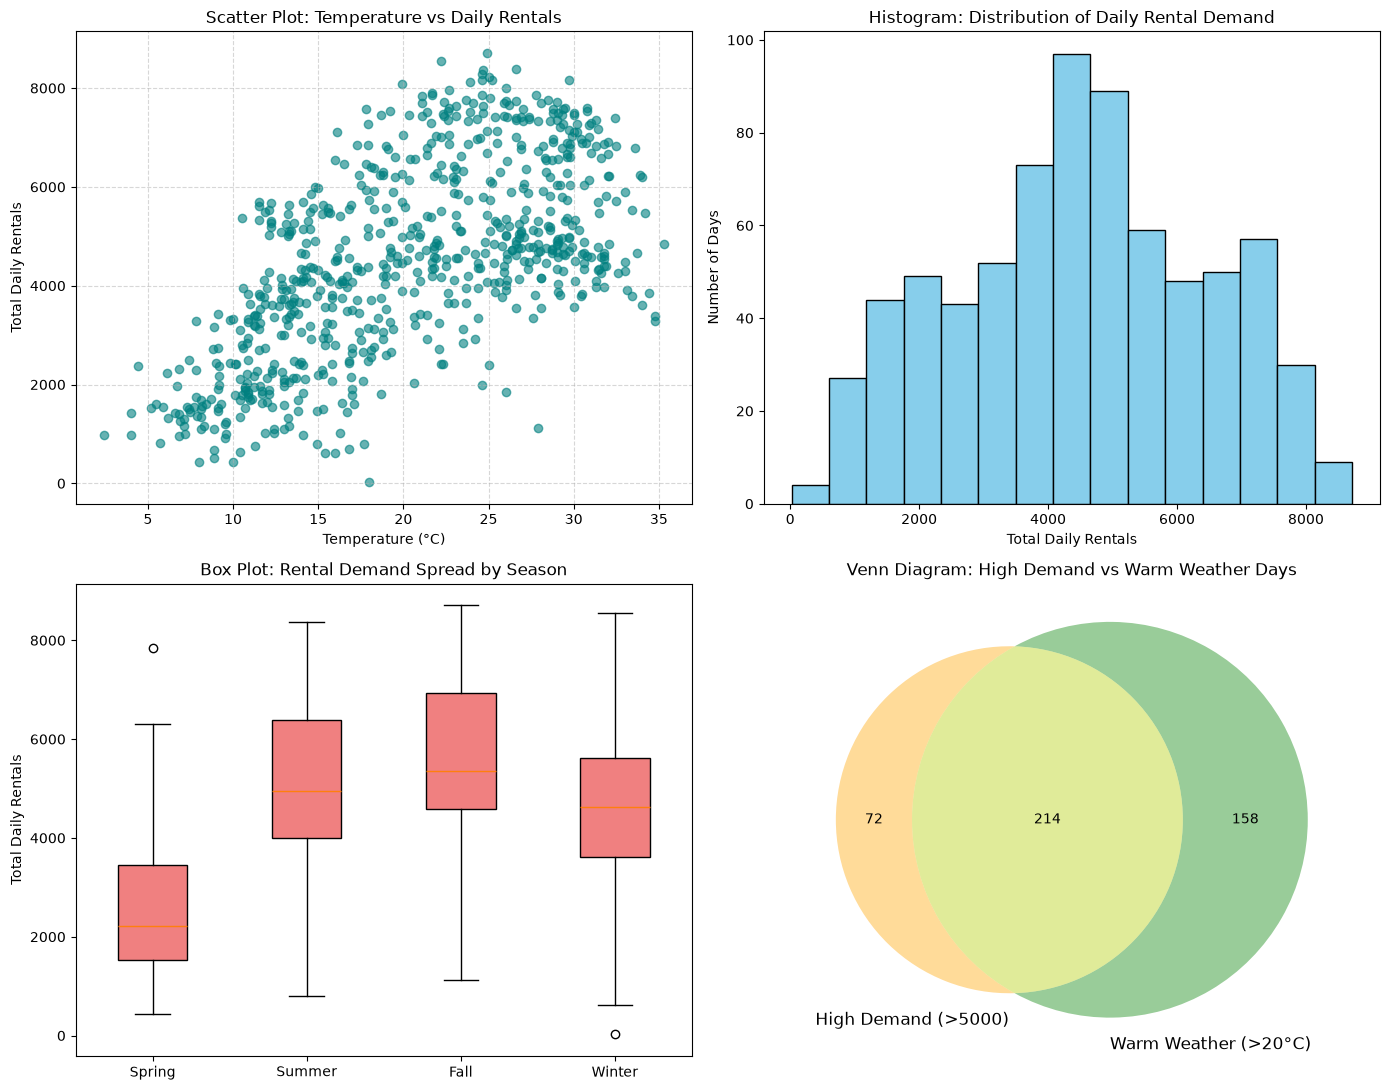

In [6]:
class BikeVisualizer(BikeDemandAnalyzer):
    
    def plot_all_visualizations(self):
        """Generates Scatter plot, Histogram, Box plot, and Venn diagram."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))

        # 1. Scatter Plot (Temperature vs Daily Bike Rentals)
        axes[0, 0].scatter(self.df['Temperature_C'], self.df['Total_Rentals'], color='teal', alpha=0.6)
        axes[0, 0].set_title('Scatter Plot: Temperature vs Daily Rentals')
        axes[0, 0].set_xlabel('Temperature (°C)')
        axes[0, 0].set_ylabel('Total Daily Rentals')
        axes[0, 0].grid(True, linestyle='--', alpha=0.5)

        # 2. Histogram (Distribution of Daily Rentals)
        axes[0, 1].hist(self.df['Total_Rentals'], bins=15, color='skyblue', edgecolor='black')
        axes[0, 1].set_title('Histogram: Distribution of Daily Rental Demand')
        axes[0, 1].set_xlabel('Total Daily Rentals')
        axes[0, 1].set_ylabel('Number of Days')

        # 3. Box-Whisker Plot (Rental Spread across Seasons)
        seasons = ['Spring', 'Summer', 'Fall', 'Winter']
        season_data = [self.df[self.df['Season'] == s]['Total_Rentals'] for s in seasons]
        
        axes[1, 0].boxplot(season_data, tick_labels=seasons, patch_artist=True,
                           boxprops=dict(facecolor='lightcoral'))
        axes[1, 0].set_title('Box Plot: Rental Demand Spread by Season')
        axes[1, 0].set_ylabel('Total Daily Rentals')

        # 4. Venn Diagram (High-Demand Days vs Favorable Weather Days)
        # High Demand = top 30% rental days (> 5000 rentals)
        # Favorable Weather = Warm days (> 20°C)
        high_demand = set(self.df[self.df['Total_Rentals'] > 5000].index)
        warm_weather = set(self.df[self.df['Temperature_C'] > 20].index)

        venn2([high_demand, warm_weather], 
              set_labels=('High Demand (>5000)', 'Warm Weather (>20°C)'), 
              ax=axes[1, 1],
              set_colors=('orange', 'green'))
        axes[1, 1].set_title('Venn Diagram: High Demand vs Warm Weather Days')

        plt.tight_layout()
        plt.show()

# Run visualizer
vis = BikeVisualizer(df)
vis.plot_all_visualizations()

### 1-Minute Presentation Script

"Good day everyone! Today we are presenting our analysis on city bike-sharing demand across 731 operational days.

Instead of guessing how many bikes to place on the street, we let the numbers guide us. Across our dataset, average daily rentals hovered around 4,500 bikes, but demand fluctuates significantly based on daily weather conditions.

Looking at our **Scatter Plot**, temperature shows a strong positive correlation with rentals—people naturally ride more as temperatures rise up to around 25°C. 

Our **Box Plot** clearly proves that Fall and Summer experience significantly higher baseline rental volumes compared to Winter. 

Finally, our **Venn Diagram** isolates high-demand days (over 5,000 rentals) against warm-weather days. The large intersection proves that warm weather is the primary driver of peak rental days, providing city operators with clear predictive power for scheduling bikes."